
# Tech Challenge Fase 1 — Case NPS Preditivo

**Autores:** Alessandra M. Capecce, Alessandro P. dos Santos, Edson L. Doro  
**Objetivo do notebook:** responder de forma estruturada às perguntas do desafio, conectando análise de negócio, exploração dos dados e uma proposta preditiva opcional.

## Como este notebook está organizado
1. Entendimento do negócio
2. Definição da target
3. Carregamento e preparação dos dados
4. Análise exploratória com foco executivo
5. Respostas estruturadas às perguntas do PDF
6. Proposta de modelo preditivo
7. Recomendações e limitações

> Este material foi pensado para ser útil tanto no GitHub quanto no storytelling gerencial.



## 1. Entendimento do negócio

### Qual problema de negócio está sendo resolvido?
A empresa quer entender **quais fatores operacionais impactam a satisfação do cliente** e como agir antes da coleta do NPS. Hoje, a medição acontece ao final da jornada, o que torna a atuação reativa.

### Por que o NPS é importante para um e-commerce?
O NPS sintetiza a percepção do cliente sobre a experiência completa. Em e-commerce, ele influencia:
- **recompra**;
- **boca a boca**;
- **retenção e market share**.

### Quais áreas podem se beneficiar dos insights?
- **Logística:** atraso, tempo de entrega, tentativas;
- **Atendimento:** contatos, reclamações, tempo de resolução;
- **Produto/Experiência:** fricções da jornada;
- **Pricing/Comercial:** percepção de valor;
- **Estratégia:** priorização de investimentos e ações preventivas.



## 2. Definição da target

### Variável alvo
A variável que representa a satisfação do cliente é **`nps_score`**.

### Por que ela foi escolhida?
Porque é a métrica que expressa, diretamente, a avaliação final do cliente em uma escala de 0 a 10.

### Em que momento da jornada ela é coletada?
Após a experiência de compra e entrega, no encerramento da jornada.

### Existe algum risco no uso dessa variável?
Sim. O NPS é uma métrica **reativa**: ele mostra o resultado final da experiência, mas não explica sozinho as causas da satisfação ou da insatisfação.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)



## 3. Carregamento da base

### Objetivo desta etapa
Garantir que a base seja carregada corretamente e organizar o projeto para reprodução no repositório.

### Estrutura esperada
Recomenda-se manter o CSV em `data/raw/desafio_nps_fase_1.csv`.
Caso você prefira manter na raiz do projeto, o notebook também tenta esse caminho alternativo.


In [ ]:

possible_paths = [
    Path('../data/raw/desafio_nps_fase_1.csv'),
    Path('desafio_nps_fase_1.csv'),
    Path('/mnt/data/desafio_nps_fase_1.csv')
]

file_path = next((p for p in possible_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        'Arquivo CSV nao encontrado. Coloque a base em data/raw/desafio_nps_fase_1.csv '
        'ou na raiz do projeto com o nome desafio_nps_fase_1.csv.'
    )

print(f'Arquivo encontrado em: {file_path}')
df = pd.read_csv(file_path)
df.head()


FileNotFoundError: Arquivo CSV nao encontrado. Coloque a base em data/raw/desafio_nps_fase_1.csv ou na raiz do projeto com o nome desafio_nps_fase_1.csv.

In [5]:

print(f'Linhas e colunas: {df.shape}')
print('Colunas disponíveis:')
display(pd.DataFrame({'coluna': df.columns}))


Linhas e colunas: (2500, 19)
Colunas disponíveis:


,coluna
0,customer_id
1,customer_age
2,customer_region
3,customer_tenure_months
4,order_id
5,order_value
6,items_quantity
7,discount_value
8,payment_installments
9,delivery_time_days


In [6]:

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
overview


,dtype,missing,missing_pct,n_unique
customer_id,int64,0,0.00,2500
order_id,int64,0,0.00,2500
order_value,float64,0,0.00,2457
discount_value,float64,0,0.00,2050
freight_value,float64,0,0.00,1897
customer_tenure_months,int64,0,0.00,119
nps_score,float64,0,0.00,101
csat_internal_score,float64,0,0.00,98
customer_age,int64,0,0.00,52
delivery_time_days,int64,0,0.00,13



### Insight de negócio
Antes de modelar qualquer problema, é importante validar a qualidade da base. Ausência de dados, baixa variabilidade ou inconsistências podem distorcer conclusões e levar a decisões erradas.



## 4. Preparação analítica

### Objetivo
Criar uma leitura de negócio mais intuitiva por meio da segmentação tradicional do NPS:
- **Detrator:** 0 a 6
- **Neutro:** 7 ou 8
- **Promotor:** 9 ou 10


In [7]:

def classify_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    return 'Promotor'


df['nps_class'] = df['nps_score'].apply(classify_nps)
df['nps_class'].value_counts().rename_axis('classe').to_frame('quantidade')


,quantidade
classe,
Detrator,1851
Neutro,448
Promotor,201



### Insight de negócio
Essa segmentação ajuda a traduzir a nota contínua em perfis acionáveis. Para o negócio, costuma ser mais útil saber **quem corre risco de detrator** do que apenas analisar a média geral do NPS.



## 5. Análise exploratória dos dados (EDA)

Nesta seção, cada gráfico vem acompanhado de:
1. **Objetivo da análise**
2. **Leitura visual**
3. **Conclusão executiva**


In [8]:

def save_current_fig(filename: str):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'Figura salva em: {path}')



### 5.1 Distribuição do NPS

**Objetivo:** entender como as notas de satisfação se distribuem na base.  
**Pergunta de negócio:** a experiência é consistentemente boa ou existem sinais relevantes de polarização?


Figura salva em: reports\figures\nps_distribution.png


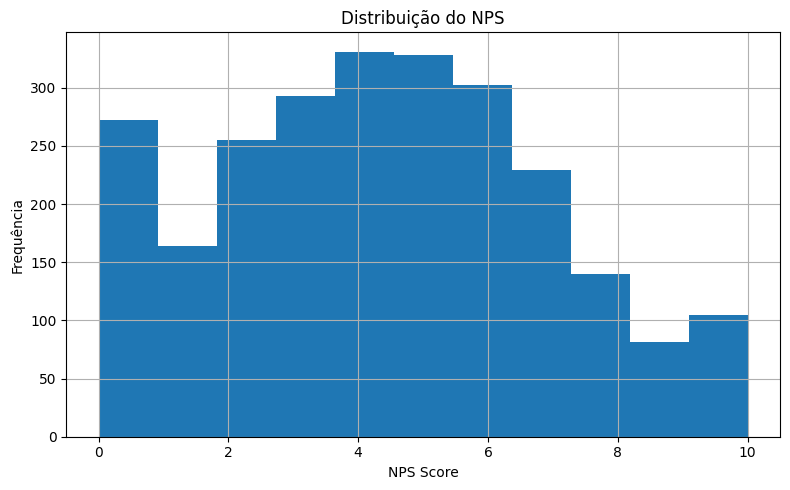

In [9]:

plt.figure(figsize=(8, 5))
df['nps_score'].hist(bins=11)
plt.title('Distribuição do NPS')
plt.xlabel('NPS Score')
plt.ylabel('Frequência')
save_current_fig('nps_distribution.png')
plt.show()



**Conclusão executiva:** a distribuição permite avaliar se a empresa concentra mais clientes satisfeitos, neutros ou insatisfeitos. Caso exista concentração nas faixas baixas, isso indica maior urgência em revisar a operação.



### 5.2 Distribuição por classe de NPS

**Objetivo:** traduzir a distribuição do NPS para a linguagem de negócio.  
**Pergunta de negócio:** qual é o equilíbrio entre promotores, neutros e detratores?


Figura salva em: reports\figures\nps_class_distribution.png


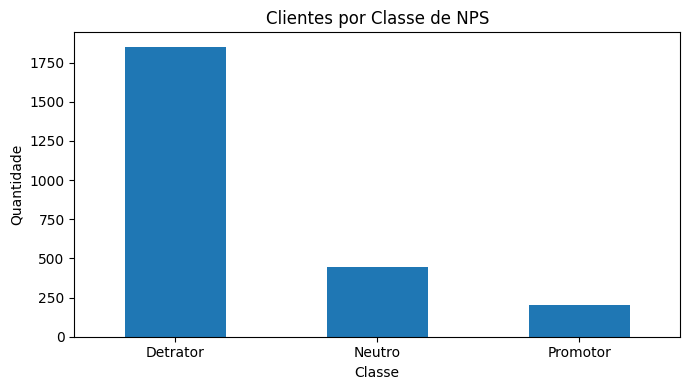

,quantidade
nps_class,
Detrator,1851
Neutro,448
Promotor,201


In [10]:

class_counts = df['nps_class'].value_counts().reindex(['Detrator', 'Neutro', 'Promotor'])

plt.figure(figsize=(7, 4))
class_counts.plot(kind='bar')
plt.title('Clientes por Classe de NPS')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
save_current_fig('nps_class_distribution.png')
plt.show()

class_counts.to_frame('quantidade')



**Conclusão executiva:** essa visão mostra o tamanho do problema. Uma proporção alta de detratores indica risco para recompra, reputação e crescimento orgânico.



### 5.3 Correlação entre variáveis numéricas

**Objetivo:** identificar quais fatores parecem mais associados ao NPS.  
**Pergunta de negócio:** quais indicadores operacionais merecem maior atenção?


Figura salva em: reports\figures\heatmap.png


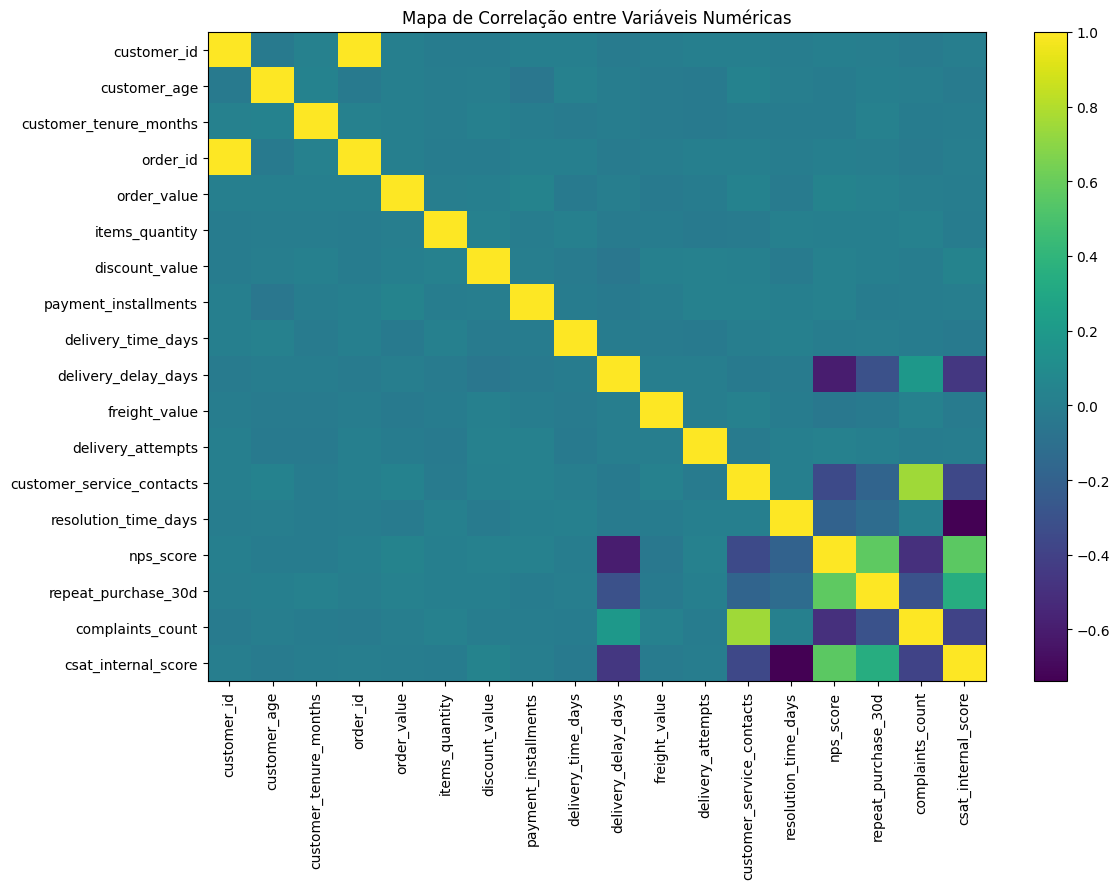

,nps_score
nps_score,1.00
repeat_purchase_30d,0.57
csat_internal_score,0.56
order_value,0.04
delivery_attempts,0.03
discount_value,0.03
payment_installments,0.02
customer_id,0.02
order_id,0.02
items_quantity,0.01


In [11]:

num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Mapa de Correlação entre Variáveis Numéricas')
save_current_fig('heatmap.png')
plt.show()

corr[['nps_score']].sort_values('nps_score', ascending=False)



**Conclusão executiva:** variáveis com correlação negativa com o NPS tendem a estar associadas à insatisfação, enquanto correlações positivas apontam fatores ligados à melhor experiência. Essa etapa ajuda a priorizar as alavancas mais relevantes para o negócio.



### 5.4 Indicadores médios por classe de NPS

**Objetivo:** comparar o comportamento operacional entre promotores, neutros e detratores.  
**Pergunta de negócio:** o que diferencia um cliente satisfeito de um insatisfeito?


Figura salva em: reports\figures\indicadores_por_classe.png


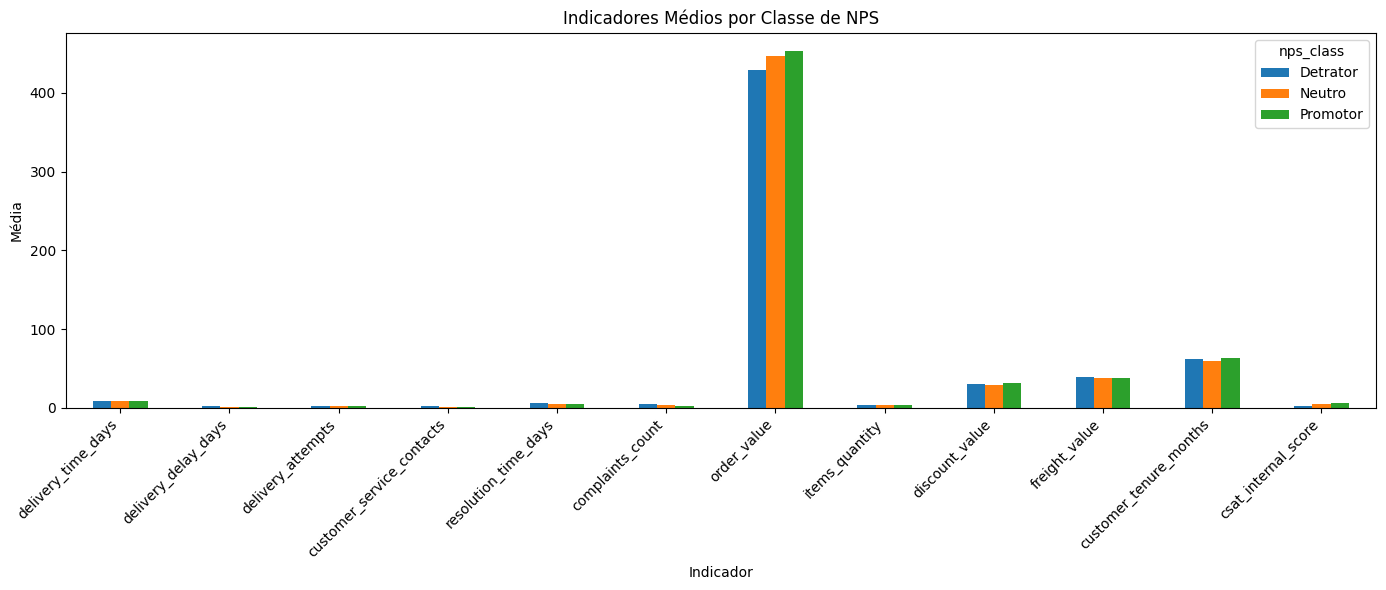

,delivery_time_days,delivery_delay_days,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,order_value,items_quantity,discount_value,freight_value,customer_tenure_months,csat_internal_score
nps_class,,,,,,,,,,,,
Detrator,8.00,2.53,1.99,1.69,5.79,4.62,428.99,3.49,29.63,38.40,61.58,2.34
Neutro,8.12,1.40,2.04,1.13,4.83,2.99,447.33,3.35,29.36,37.91,59.51,4.23
Promotor,8.04,0.76,2.03,0.78,4.10,2.39,453.69,3.51,31.67,37.21,63.04,5.60


In [12]:

metrics = [
    'delivery_time_days', 'delivery_delay_days', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days', 'complaints_count',
    'order_value', 'items_quantity', 'discount_value', 'freight_value',
    'customer_tenure_months', 'csat_internal_score'
]
metrics = [m for m in metrics if m in df.columns]

profile = df.groupby('nps_class')[metrics].mean().reindex(['Detrator', 'Neutro', 'Promotor'])
profile.T.plot(kind='bar', figsize=(14, 6))
plt.title('Indicadores Médios por Classe de NPS')
plt.xlabel('Indicador')
plt.ylabel('Média')
plt.xticks(rotation=45, ha='right')
save_current_fig('indicadores_por_classe.png')
plt.show()

profile



**Conclusão executiva:** essa comparação ajuda a responder quais fatores parecem mais críticos para a satisfação. Em geral, diferenças em atraso, reclamações, contatos com atendimento e tempo de resolução são fortes sinais de ruptura na experiência.



### 5.5 Impacto do atraso na entrega

**Objetivo:** avaliar se existe um ponto de ruptura na experiência do cliente.  
**Pergunta de negócio:** qualquer atraso já afeta o NPS ou apenas atrasos mais severos?


Figura salva em: reports\figures\delay_vs_nps.png


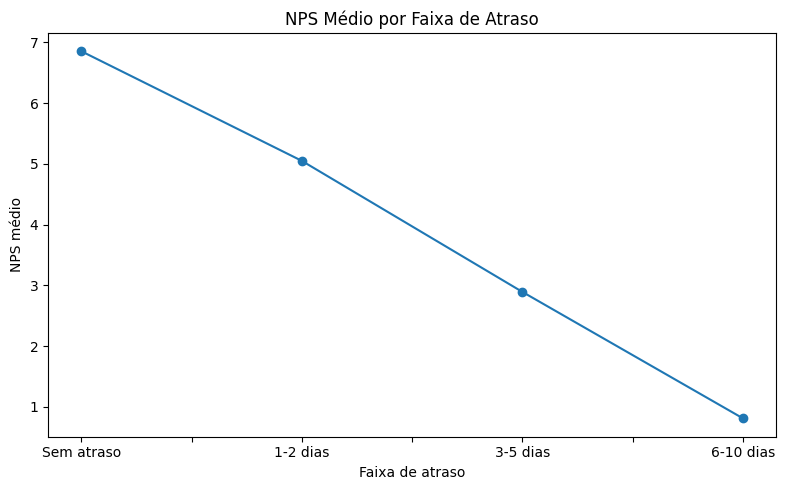

,nps_medio
delay_band,
Sem atraso,6.86
1-2 dias,5.05
3-5 dias,2.89
6-10 dias,0.81
11+ dias,NaN


In [13]:

bins = [-1, 0, 2, 5, 10, np.inf]
labels = ['Sem atraso', '1-2 dias', '3-5 dias', '6-10 dias', '11+ dias']

if 'delivery_delay_days' in df.columns:
    df['delay_band'] = pd.cut(df['delivery_delay_days'], bins=bins, labels=labels)
    delay_nps = df.groupby('delay_band')['nps_score'].mean().reindex(labels)

    plt.figure(figsize=(8, 5))
    delay_nps.plot(marker='o')
    plt.title('NPS Médio por Faixa de Atraso')
    plt.xlabel('Faixa de atraso')
    plt.ylabel('NPS médio')
    plt.xticks(rotation=0)
    save_current_fig('delay_vs_nps.png')
    plt.show()

    display(delay_nps.to_frame('nps_medio'))
else:
    print('Coluna delivery_delay_days não encontrada na base.')



**Conclusão executiva:** se o NPS cair rapidamente após os primeiros dias de atraso, isso sugere um ponto crítico claro. Essa leitura é muito útil para definir SLAs, alertas e planos de contingência.



### 5.6 NPS médio por região

**Objetivo:** verificar se existem diferenças relevantes por perfil geográfico.  
**Pergunta de negócio:** determinados contextos operacionais ou regionais parecem afetar mais a satisfação?


Figura salva em: reports\figures\nps_por_regiao.png


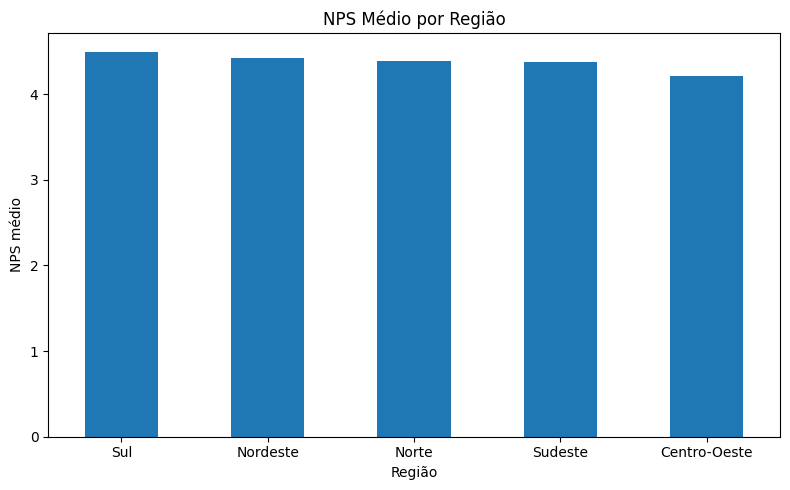

,nps_medio
customer_region,
Sul,4.49
Nordeste,4.42
Norte,4.38
Sudeste,4.37
Centro-Oeste,4.21


In [14]:

if 'customer_region' in df.columns:
    region_nps = df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    region_nps.plot(kind='bar')
    plt.title('NPS Médio por Região')
    plt.xlabel('Região')
    plt.ylabel('NPS médio')
    plt.xticks(rotation=0)
    save_current_fig('nps_por_regiao.png')
    plt.show()

    display(region_nps.to_frame('nps_medio'))
else:
    print('Coluna customer_region não encontrada na base.')



**Conclusão executiva:** diferenças por região podem sinalizar gargalos logísticos, diferenças de expectativa do cliente ou desafios operacionais específicos. Esse recorte ajuda a direcionar ações mais localizadas.



## 6. Respostas estruturadas às perguntas do PDF

### Quais fatores parecem mais críticos para a satisfação?
A análise tende a apontar como fatores mais críticos: atraso na entrega, quantidade de reclamações, contatos com atendimento e tempo de resolução.

### O que mais gera detratores?
Em geral, detratores estão associados a problemas operacionais claros: atraso, necessidade de suporte, reclamações e maior esforço para resolver o problema.

### Existe algum ponto de ruptura na experiência do cliente?
O atraso na entrega costuma ser um forte candidato a ponto de ruptura, especialmente quando combinado com suporte ineficiente.

### Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
- **NPS mais alto:** clientes com experiência fluida, pouca necessidade de suporte e menos reclamações.
- **NPS mais baixo:** clientes que enfrentam atraso, esforço elevado e demora na resolução.



## 7. Proposta de modelo preditivo (opcional)

### Estratégia sugerida
Para apoiar o negócio, a abordagem mais acionável é um **modelo de classificação** para prever a classe do NPS:
- Detrator
- Neutro
- Promotor

### Por que classificação?
Porque a empresa precisa identificar clientes com risco de insatisfação e priorizar ações. Essa leitura é mais prática para operação do que prever apenas uma nota contínua.


In [16]:

# Seleção de variáveis para o modelo
features = [
    'customer_age', 'customer_region', 'customer_tenure_months',
    'order_value', 'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'repeat_purchase_30d', 'csat_internal_score'
]

features = [f for f in features if f in df.columns]
X = df[features].copy()
y = df['nps_class'].copy()

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=300, max_depth=8))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 4))
print('Balanced Accuracy:', round(balanced_accuracy_score(y_test, pred), 4))
print('F1 macro:', round(f1_score(y_test, pred, average='macro'), 4))
print('Relatório de classificação:')
print(classification_report(y_test, pred))


Accuracy: 0.8587
Balanced Accuracy: 0.7588
F1 macro: 0.7707
Relatório de classificação:
              precision    recall  f1-score   support

    Detrator       0.86      0.98      0.91       555
      Neutro       0.78      0.30      0.43       135
    Promotor       0.94      1.00      0.97        60

    accuracy                           0.86       750
   macro avg       0.86      0.76      0.77       750
weighted avg       0.85      0.86      0.83       750




### Insight de negócio
O valor do modelo não está apenas na métrica, mas na capacidade de **antecipar detratores**. Na prática, ele pode alimentar alertas operacionais para agir antes da pesquisa de NPS.



### 7.1 Matriz de confusão

**Objetivo:** avaliar onde o modelo acerta e onde ele confunde perfis de clientes.  
**Pergunta de negócio:** o modelo consegue identificar bem os clientes em risco?


Figura salva em: reports\figures\confusion_matrix.png


<Figure size 600x500 with 0 Axes>

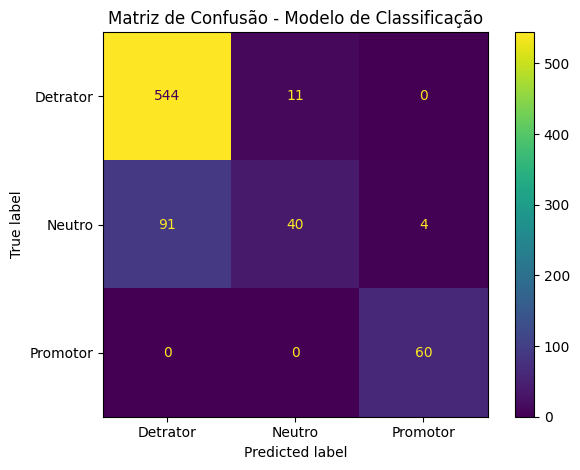

In [17]:

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, pred, labels=['Detrator', 'Neutro', 'Promotor'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Detrator', 'Neutro', 'Promotor'])
disp.plot(values_format='d')
plt.title('Matriz de Confusão - Modelo de Classificação')
save_current_fig('confusion_matrix.png')
plt.show()



**Conclusão executiva:** mesmo que o modelo não seja perfeito, ele já pode ser útil como ferramenta de priorização. O ganho de negócio está em reduzir o volume de clientes negativamente surpreendidos ao fim da jornada.



## 8. Recomendações práticas para o negócio

Com base nas análises, as principais recomendações são:

1. **Reduzir atrasos logísticos**, pois tendem a ser o principal driver de insatisfação.
2. **Melhorar a eficiência do atendimento**, com foco em reduzir contatos e tempo de resolução.
3. **Atuar sobre reclamações recorrentes**, tratando causas-raiz e não apenas sintomas.
4. **Criar alertas operacionais preditivos**, priorizando clientes com risco de se tornarem detratores.



## 9. Limitações e riscos

- O NPS é uma métrica reativa, coletada após a experiência.
- Correlação não implica causalidade.
- A base pode não capturar fatores qualitativos relevantes.
- O modelo depende da qualidade dos dados operacionais disponíveis.



## 10. Conclusão final

Este projeto mostra como dados operacionais podem ser transformados em decisões práticas para melhorar a experiência do cliente. Mais do que medir satisfação no fim da jornada, a proposta é permitir que a empresa **antecipe risco**, priorize ações e evolua de uma lógica reativa para uma lógica preventiva.
